Projek ini bertujuan untuk membuat model machine learning sederhana menggunakan Decision tree untuk membangun model yang bisa mendeteksi penyakit jantung berdasarkan data medis pasien.

In [9]:
import pandas as pd #library untuk menampilkan data dalam bentuk tabel
import matplotlib.pyplot as plt #library untuk menampilkan data dalam bentuk grafik
from sklearn.model_selection import train_test_split #library untuk membagi data menjadi data latih dan data uji
from sklearn.tree import DecisionTreeClassifier #library untuk membuat model decision tree
from sklearn import tree #library untuk visualisasi tree
from sklearn.metrics import classification_report, confusion_matrix #library untuk mengevaluasi model
#import dataset heart
df = pd.read_csv("heart.csv")
print(df.head()) #menampilkan 5 baris pertama dari dataset
print(df.info()) #menampilkan informasi tentang dataset

#Eksplorasi data
print(df.describe()) #menampilkan statistik deskriptif dari dataset
#preprocessing
#mengubah tipe data menjadi kategori
df["sex"] = df["sex"].astype("category") 
df["target"] = df["target"].astype("category")

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

Karena pada dataset heart semua variabelnya adalah numerik namun terdapat 2 variabel yang seharusnya kategorik yaitu sex dan target maka kita ubah ke dalam kategorik 

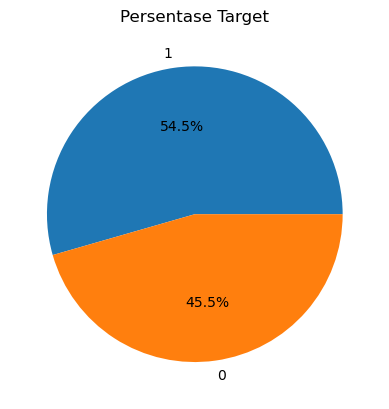

In [12]:
#visualisasi data target dengan pie chart
plotdata = df["target"].value_counts(normalize=True) * 100
plt.pie(plotdata, labels=plotdata.index, autopct='%1.1f%%')
plt.title("Persentase Target")
plt.show()

Dari visualisasi target dengan pie chart diketahui distribusi 1 (laki-laki) sebesar 54.5% dan distribusi 0 (perempuan) sebesar 45.5% 

In [ ]:
#splitting data
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

#modeling Decision Tree
model = DecisionTreeClassifier(random_state=123)
#fit model atau melatih model dengan data latih
model.fit(X_train, y_train)
#prediksi dengan data uji
y_pred = model.predict(X_test)

#evaluasi confusion matrix dan akurasi
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
akurasi = (cm[0][0] + cm[1][1]) / cm.sum()
print(f"Akurasi: {akurasi:.2f}")



Confusion Matrix:
[[23  7]
 [ 8 23]]
Akurasi: 0.75


Berdasarkan hasil perhitungan dengan menggunakan Decision Tree didapatkan akurasi sebesar 75% yang menunjukkan bahwa model cukup mampu melakukan klasifikasi.

[Text(0.47115384615384615, 0.95, 'cp <= 0.5\ngini = 0.494\nsamples = 242\nvalue = [108, 134]\nclass = Sakit'),
 Text(0.21794871794871795, 0.85, 'ca <= 0.5\ngini = 0.38\nsamples = 110\nvalue = [82.0, 28.0]\nclass = Tidak Sakit'),
 Text(0.34455128205128205, 0.8999999999999999, 'True  '),
 Text(0.1282051282051282, 0.75, 'thal <= 2.5\ngini = 0.498\nsamples = 47\nvalue = [22, 25]\nclass = Sakit'),
 Text(0.07692307692307693, 0.65, 'oldpeak <= 1.7\ngini = 0.293\nsamples = 28\nvalue = [5, 23]\nclass = Sakit'),
 Text(0.05128205128205128, 0.55, 'thalach <= 96.5\ngini = 0.204\nsamples = 26\nvalue = [3, 23]\nclass = Sakit'),
 Text(0.02564102564102564, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Tidak Sakit'),
 Text(0.07692307692307693, 0.45, 'age <= 60.0\ngini = 0.147\nsamples = 25\nvalue = [2, 23]\nclass = Sakit'),
 Text(0.05128205128205128, 0.35, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]\nclass = Sakit'),
 Text(0.10256410256410256, 0.35, 'age <= 61.5\ngini = 0.408\nsamples = 7\nvalu

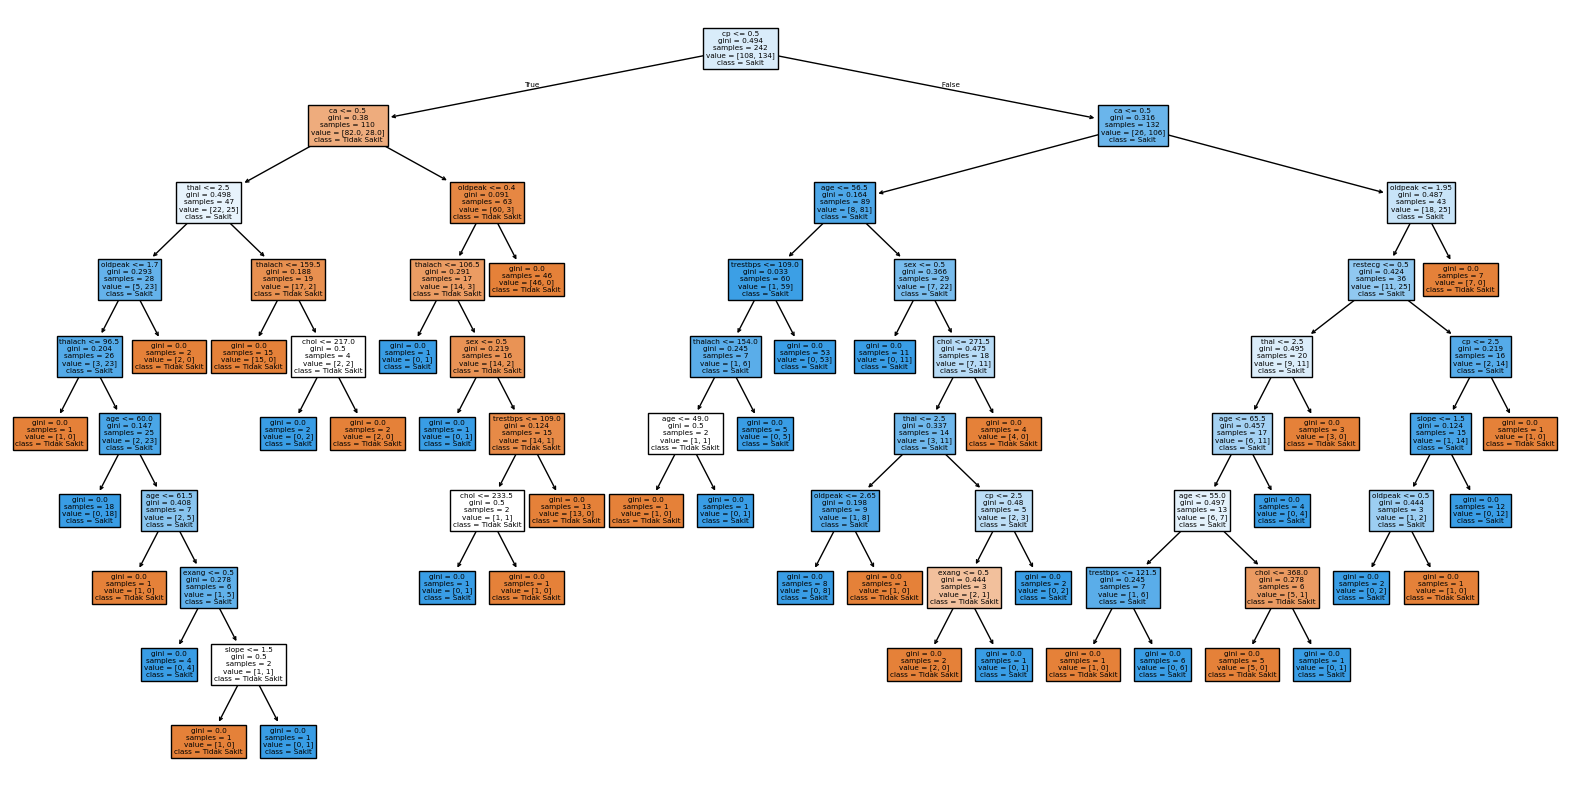

In [17]:
#visualisasi tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["Tidak Sakit", "Sakit"]
)

Berdasarkan hasil penelitian, model machine learning menggunakan metode Decision Tree dapat digunakan untuk mendeteksi penyakit jantung berdasarkan data medis pasien. Model yang dibangun menghasilkan akurasi sebesar 75%, yang menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam melakukan klasifikasi. Meskipun demikian, masih terdapat kemungkinan kesalahan prediksi, sehingga diperlukan pengembangan lebih lanjut seperti optimasi parameter atau penggunaan metode lain untuk meningkatkan performa model.